# 6. RnnVisual

Visualisasi hasil RNN/LSTM dari artefak yang sudah tersimpan.


In [9]:
from pathlib import Path
import sys

def find_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start] + list(start.parents):
        if (path / 'src').exists() and (path / 'data').exists():
            return path
    raise RuntimeError('root repo tidak ditemukan')

ROOT = find_root()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print('root:', ROOT)


root: /Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic


In [10]:
import json
import pandas as pd
import matplotlib.pyplot as plt

TABLE_DIR = ROOT / 'reports/tables/rnn'
FIG_DIR = ROOT / 'reports/figures/rnn'
FIG_DIR.mkdir(parents=True, exist_ok=True)

scores = pd.read_csv(TABLE_DIR / 'rnn_lstm_results.csv')
comparison = pd.read_csv(TABLE_DIR / 'keras_vs_scratch.csv')
lengths = pd.read_csv(TABLE_DIR / 'length_scores.csv')
qualitative = pd.read_csv(TABLE_DIR / 'qualitative_examples.csv')
train_records = json.loads((TABLE_DIR / 'train_records.json').read_text(encoding='utf-8'))
expected = {Path(row['model_path']).name for row in train_records}
actual = {Path(row).name for row in scores['model_path'].astype(str)}
missing = sorted(expected - actual)
print('rnn:', len(scores), '/', len(expected), 'compare:', len(comparison), 'length:', len(lengths), 'contoh:', len(qualitative))
if missing:
    print('belum ada skor:', ', '.join(missing))


rnn: 9 / 12 compare: 4 length: 3 contoh: 10
belum ada skor: lstm_layers2_hidden512_len33.keras, lstm_layers3_hidden128_len33.keras, lstm_layers3_hidden512_len33.keras


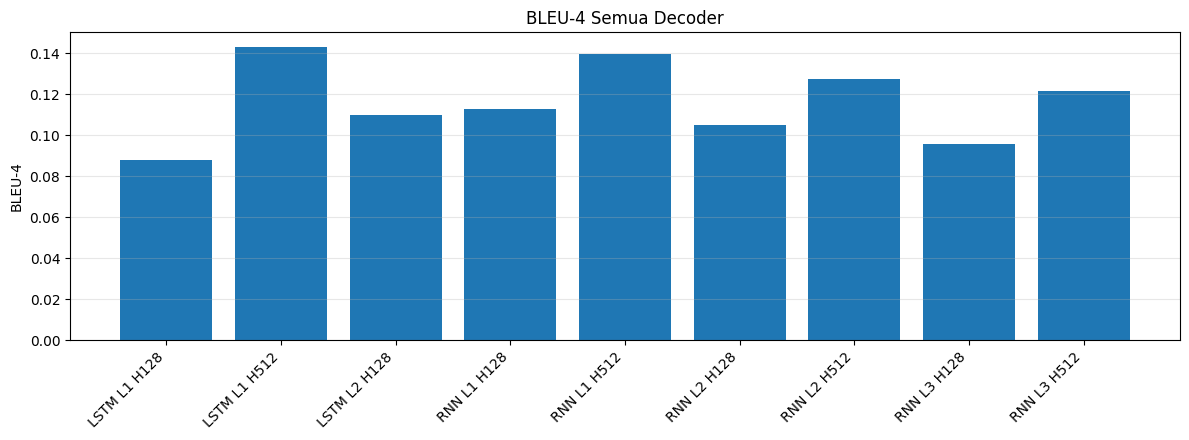

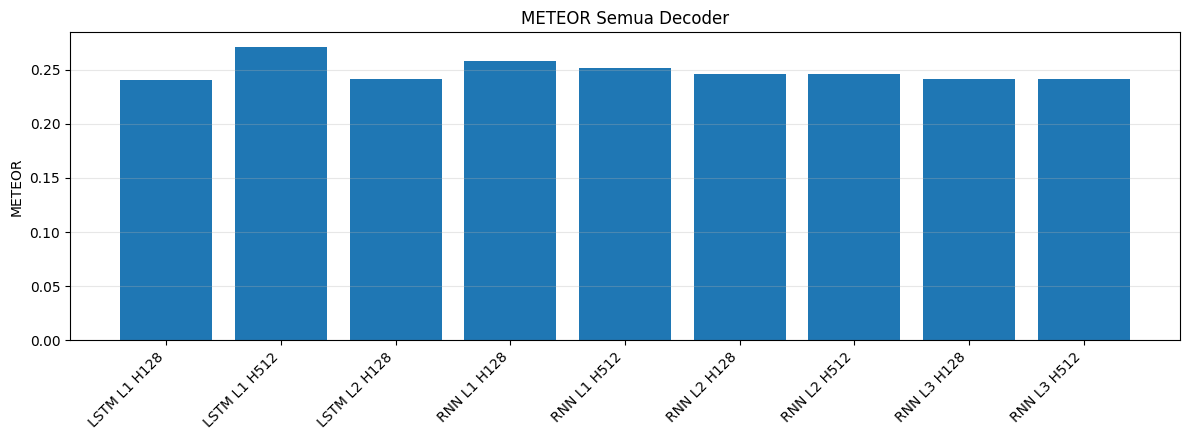

In [11]:
plot_scores = scores.copy().sort_values(['recur_type', 'recur_layers', 'hidden_size'])
plot_scores['label'] = plot_scores.apply(lambda row: f"{row['recur_type'].upper()} L{int(row['recur_layers'])} H{int(row['hidden_size'])}", axis=1)

plt.figure(figsize=(12, 4.5))
plt.bar(plot_scores['label'], plot_scores['bleu4'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('BLEU-4')
plt.title('BLEU-4 Semua Decoder')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rnn_lstm_bleu4_variations.png', dpi=150)
plt.show()

plt.figure(figsize=(12, 4.5))
plt.bar(plot_scores['label'], plot_scores['meteor'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('METEOR')
plt.title('METEOR Semua Decoder')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rnn_lstm_meteor_variations.png', dpi=150)
plt.show()


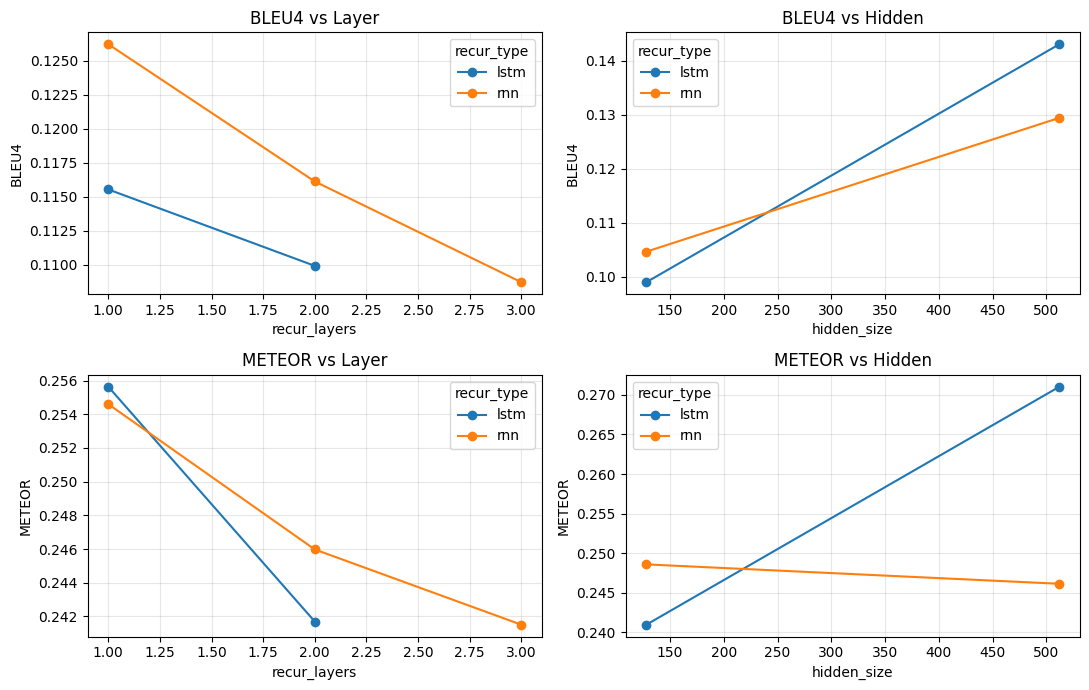

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for metric, row_axes in [('bleu4', axes[0]), ('meteor', axes[1])]:
    scores.groupby(['recur_type', 'recur_layers'])[metric].mean().unstack(0).plot(marker='o', ax=row_axes[0])
    row_axes[0].set_title(f'{metric.upper()} vs Layer')
    row_axes[0].set_ylabel(metric.upper())
    row_axes[0].grid(alpha=0.3)
    scores.groupby(['recur_type', 'hidden_size'])[metric].mean().unstack(0).plot(marker='o', ax=row_axes[1])
    row_axes[1].set_title(f'{metric.upper()} vs Hidden')
    row_axes[1].set_ylabel(metric.upper())
    row_axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rnn_layer_hidden_effects.png', dpi=150)
plt.show()


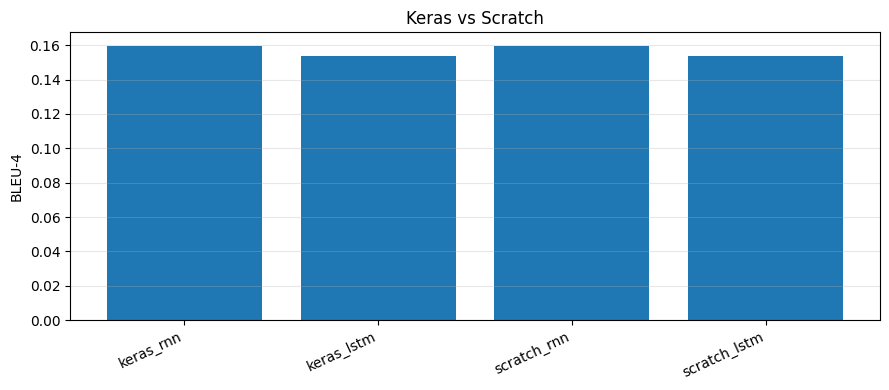

In [13]:
plt.figure(figsize=(9, 4))
labels = comparison['implementation'].astype(str) + '_' + comparison['recur_type'].astype(str)
plt.bar(labels, comparison['bleu4'])
plt.xticks(rotation=25, ha='right')
plt.ylabel('BLEU-4')
plt.title('Keras vs Scratch')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rnn_keras_vs_scratch.png', dpi=150)
plt.show()


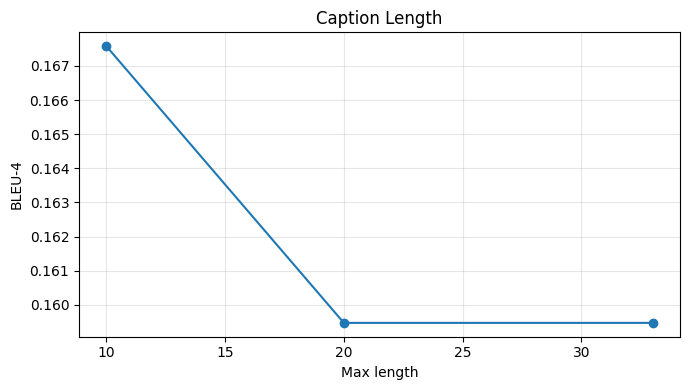

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(lengths['max_length'], lengths['bleu4'], marker='o')
plt.xlabel('Max length')
plt.ylabel('BLEU-4')
plt.title('Caption Length')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'length_bleu4.png', dpi=150)
plt.show()


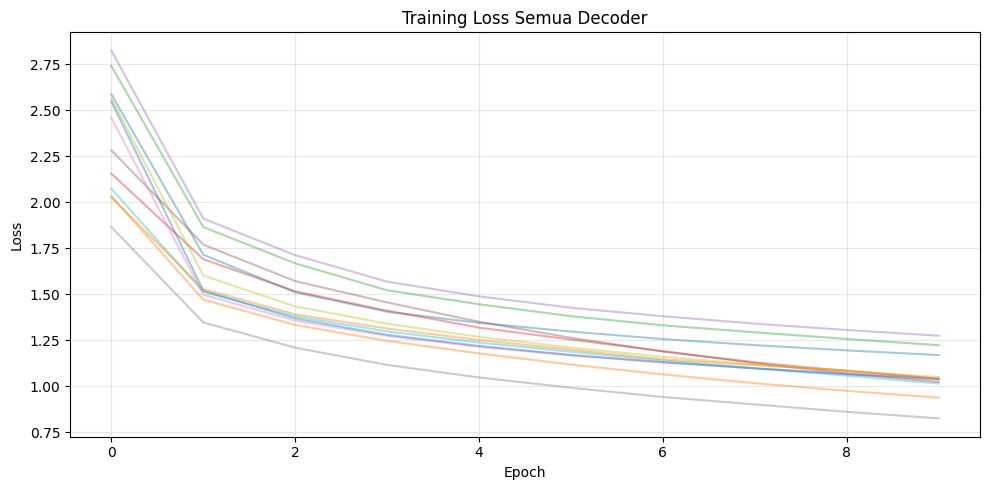

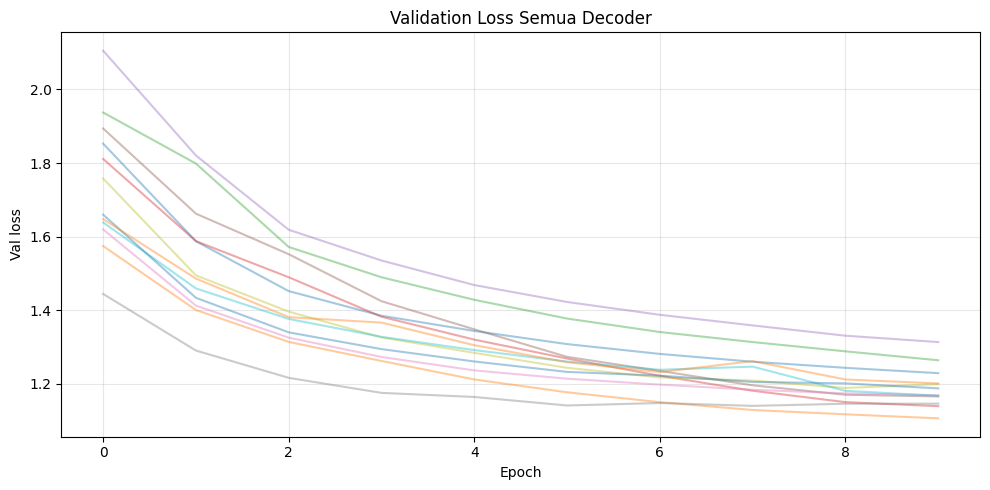

In [15]:
plt.figure(figsize=(10, 5))
for hist_path in sorted(TABLE_DIR.glob('*_history.json')):
    history = json.loads(hist_path.read_text(encoding='utf-8'))
    label = hist_path.stem.replace('_history', '')
    values = history.get('loss', [])
    if values:
        plt.plot(values, alpha=0.4, label=label)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Semua Decoder')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'training_loss_curves.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
for hist_path in sorted(TABLE_DIR.glob('*_history.json')):
    history = json.loads(hist_path.read_text(encoding='utf-8'))
    label = hist_path.stem.replace('_history', '')
    values = history.get('val_loss', [])
    if values:
        plt.plot(values, alpha=0.4, label=label)
plt.xlabel('Epoch')
plt.ylabel('Val loss')
plt.title('Validation Loss Semua Decoder')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'validation_loss_curves.png', dpi=150)
plt.show()


In [16]:
qualitative.head(10)


,avg_bleu4,ground_truth_refs,image_id,lstm_prediction,rnn_prediction
0,0.017165,"['a small dog walks with men in the city', 'so...",3353278454_2f3a4d0bbc.jpg,a man in a white shirt and a white hat is stan...,a man in a red jacket is standing in front of ...
1,0.023675,"['a group of people wait in similar attire', '...",536537638_f5ee42410b.jpg,a man in a blue shirt and a white shirt is hol...,a woman in a black shirt and tie is smiling
2,0.027081,['a hiker walks on rocky ground at the base of...,455611732_d65bf3e976.jpg,a man is riding a bike down a dirt road,a man is riding a horse on a racetrack
3,0.028634,['a big dog is biting a smaller dog on the leg...,2768972186_92787cd523.jpg,two dogs are playing with a toy,two dogs are playing in a field
4,0.058884,['a man bracing himself against the pull of a ...,2664103423_c539f61016.jpg,a man is skiing down a snowy hill,a man in a wetsuit is surfing on a boat
5,0.060389,"['two girls playing at a playground', 'two gir...",3454988449_1de1ef4f20.jpg,a young boy jumps off a swing,a boy is jumping in a puddle
6,0.060535,['a boy and girl playing with buckets in a law...,2830869109_c4e403eae6.jpg,a girl in a pink shirt and a white shirt is pl...,a girl in a pink shirt is running on a beach
7,0.061323,['a boy in a white shirt and blue shirts is pl...,3163563871_cef3cf33ea.jpg,a man in a blue shirt is playing with a soccer...,a tennis player in a blue uniform is running t...
8,0.116951,['a man holding a sign with people walking aro...,251958970_fa6b423f23.jpg,a man in a blue shirt and a white shirt is sit...,a man in a leather jacket and tie earrings
9,0.119981,"['a man is wind sailing in the ocean', 'a man ...",3037558954_20115165e3.jpg,a young boy is jumping off a slide into a pool,a man is surfing on a beach
